In [84]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# CONFIG
# ---------------------------
LABELS_CSV = "/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/labels_updated.csv"   # your master file list
ABNORMAL_DIR = "/media/dll-1/SSD 4TB/EEG Datasets/nmt_4k_split/csv/"                 # folder where mh_*.csv abnormality files live

# ---------------------------
# 1) Your abnormality dictionary (paste your full ab_label_dict_detail here)
# ---------------------------
ab_label_dict_detail = [
    ['Normal', 
     'Beta Wave','Beta waves', 'beta waves', 'Beta Wave', 'beta activity',
     'Alpha Coma', 'alpha coma'],

    # Sharp Wave
    ['Sharp Wave',
     'sharp waves', 'sharp wave', 'generalized sharp waves', 'generalized sharp waves discharge', 'Sharp Wave', 'sharp and wave', 'sharp wave discharges', 'sharp wave pre del both',
     'Triphasic Wave', 'triphasic waves', 'periodic & semiperiodic & triphasic wave', 'periodic & semiperiodic & triphasic wave  & complexes', 'periodic & semiperiodic & triphasic wave & sharp & slow wave & complexes', 'semi periodic triphasic', 'semi periodic triphasic wave', 'semiperiodic triphasic wave complexes', 'triphaic waves', 'triphasic waves ( sharp waves)', 'triphasic waves (sharp waves)', 'semiperiodic triphasic wavecomplexes', 'semiperiodic  triphasic wave',"triphasic waves'",
     'Burst Suppression', 'burst suppression', 'burst suppression pattern',
     'Sharp and slow Wave', 'focal sharp and slow wave', 'sharp and delta waves', 'sharp & delta wave', 'sharp & slow wave activity', 'sharp and delta slow wave', 'sharp and slow wave activity', 'sharp and slow wave discharges', 'slow and sharp wave', 'sharp & delta slow waves', 'sharp and deta wave', 'sharp ans slow wave discharges', 'sharp and delta slow waves', 'sharp and delta waves', 'sharp and delta wave', 'sharp and slow waves', 'sharp and slow wave', 'sharp and delta slow waves'
    ],

    # Delta Slow Wave
    ['Delta Slow Wave',
     'delta slow wave', 'delta waves', 'delta slow waves', 'slowing wave',
     'generalized paroxymal delta slow waves', 'generalized paroxysmal delta slow waves',
     'generalized parosysmal delta slow waves', 'generalized delta slow waves', 'slow waves',
     'generalized delta slow waves', 'paroxysmal delta slow waves', 'delta slow waves', 'delta waves',
     'paroxysmal generalized delta slow waves', 'paroxysmal generalized deta slow waves',
     'Delta', 'delta wave', 'Delta Slow Wave', 'changegeneralized delta slow waves', 'dela slow waves',
     'delta slow waves with muscle artifacts', 'delta slowing', 'frontal delta slowing',
     'frontal slow wave', 'frontal slow wave activity', 'generalized delta slow waves discharge',
     'generalized delta slowing', 'generalized slowing', 'generalized slowing in delta range',
     'gereralized slow wave activity', 'high amplitude polymorphic slowing with multifocal spike and wave',
     'mild  slowing', 'mild generalized slowing', 'slow wave', 'slow wave activity', 'slow wave discharges',
     'delta slow waves\\', 'delta wavest', 'delta low waves', 'delta slo waves', 'delta sloww aves',
     'delta sloww waves', 'delta slowwaves', 'generaliaed slowing', 'generalize slowing',
     'generalized  slowing', 'generalizied slowing', 'generalizwd delta slowing', 'generilized slowing',
     'generlized slowing', 'generralized slowing', 'mild generilized slowing', 'mild generlized slowing',
     'delta prev','Generalized slowing mixed with Artifacts'],

    # Spike and Wave
    ['Spike and Wave',
     '2 hertz slow spike and wave discharge', 'spike wave', 'spikes',
     'generalized paroxysmal spike and wave discharge', 'generalized paroxymal spike and wave discharge',
     'fragmented spike and wave discharge',
     'generalized paroxysmal 3 hertz spike and wave discharge',
     'generalized paroxysmal  spike and wave discharge',
     'generalized spike and wave discharge', 'generalized spike and wave discharges',
     'generalized 4 hertz spike and wave discharge', 'spike and wave', 'spike and wave discharge',
     'Generalized 3 hertz spike and wave', 'generalized 3 hertz spike and wave discharge',
     'generalized 3 hertz spike and wave activity', 'generalized 2 hertz spike and wave discharge',
     'generalized 2 hertz spike and wave', '2 hertz spike and wave discharge', 'spike and waves',
     '3 hertz fragmented spike and wave discharge', 'generalized spike and wave',
     'generalized spike and wave activity', 'spike and wave ',
     'Generalized  paroxysmal 4 hertz spike and wave discharge',
     'generalized 3.5 hertz spike and wave discharge',
     'generalized 3 hertz spike and wave discharges',
     'generalized 2 hertz spike and wave discharges', '3 hertz spike and wave discharge',
     ' 3 hertz spike and wave discharge', 'paroxysmal generalized 3.5 spike and wave discharge',
     'paroxysmal generalized 3.5 hertz spike and wave discharge', ' spike and wave discharge',
     'generalized spike  and wave discharge', 'generalized  3 hertz spike and wave discharge',
     'generalized  spike and wave discharge', 'generalized 3 hertz  spike and wave discharge',
     'spike an dwave', 'spike',
     'Paroxysmal generalized 3 hertz spike and wave discharge',
     'paroxysmal generalized spike and wave discharge',
     'paroxysmal generalized 3 hertz spike and wave discharge',
     'paroxysmal generalized 4 hertz spike and wave discharge',
     'generalized paroxysmal 3.5 spike and wave discharge',
     'spike and wave discharge 3 hertz', 'fragemented spike and wave discharge',
     'fragmented 3 hertz spike and wave discharge', 'generalized  2 hertz spike and wave discharge',
     'generalized 2 hertz  spike and wave discharge',
     'parosysmal generalized 3 hertz spike and wave discharge', 'spiek and wave',
     'generalized 2.5 hertz spike and wave discharge', 'Spike and Wave Discharge',
     '3hz spike and wave', '3hz spike and wave discharges', 'brust of spike and wave',
     'generalized 3 hertz spike and wave burst', 'generalized 3 hertzspike and wave discharge',
     'generalized periodic epileptiform discharges', 'generalized spike and wave burst',
     'generalized spike and wave dsicharge', 'generalized3 hertz spike and wave discharge',
     'spike &  wave discharges', 'spike & wave discharges', 'spike and  wave',
     'spike and wave (myoclonic jerk discharge)', 'spike and wave activity',
     'spike and wave discharges', 'spike and wave discharges\\', 'spike snd wave',
     'spike snd wave in frontal area', 'spike snd wave more porminant in frontal area',
     'spike snd wave more prominant in frontal area', 'slow spike and wave',
     'Generalized periodic epileptiform discharges\\', 'spike and wave dischages',
     'Rolandic Spikes', 'rolandic spike', 'rolandic spikes', 'rolandic spikes'
     ],
     
	 # Polyspike
    ['Polyspike',
     'generalized plolyspikes discharge', 'generalized polyspike pattern',
     'polyspike and wave discharges', 'polyspike wave discharges', 'polyspikes & wave',
     'polypspikes and wave', 'generalized polyspikes discharge',
     'generalized polyspike discharge', 'generalized polyspikes discharge',
     'polyspikes discharge', 'polyspikes and wave', 'polyspikes', 'polypspikes and wave',
     'polyspike and wave'],

    # Spike Wave and Polyspike Wave (mixed)
    ['Spike Wave and Polyspike Wave',
     'generalized spike & polyspike pattern', 'generalized spike & polyspike wave',
     'spike & poilyspike wave', 'spike & polyspike',
     'spike & polyspike  and wave discharges', 'spike & polyspike and wave',
     'spike & polyspike and wave discharges',
     'spike & polyspike and wave discharges mixed with artifacts',
     'spike & polyspike and wave discharges with artifacts', 'spike & polyspike wave',
     'spike & polyspike wave discharges', 'spike & polyspike wave pattern',
     'spike &polyspike and wave discharges', 'spike / polyspike and wave discharges',
     'spike /polyspike and wave discharges', 'spike and polyspike wave',
     'spike/polyspike and wave discharges'],


    # Theta Wave
    ['Theta Wave',
     'theta waves', 'Theta Wave', 
     'Theta Slow Wave', 'generalized slowing in theta range', 'mild generilized slowing in theta range', 'theta slow waves', 'theta wavs'
    ],

    # Delta and Theta Wave (mixed slowing)
    ['Delta and Theta Wave',
     'delta and theta waves', 'delta-theta slowing', 'frontal dela to theta slowing',
     'generalized slowing in delta to theta range', 'generalized slowing in delta-thta range'],

    # Spike And Delta slow waves (spike-and-wave followed by slowing)
    ['Spike And Delta Slow Waves',
     'spike and delta slow waves', 'spike and wave discharges followed by generalized slowing',
     'spike and wave discharges followed by slowing',
     'spike and wave discharges with generalized slowing'],
     
	   # Low Voltage / No waveform
    ['Low Voltage',
     'low voltage', 'no waveform', 'Low Voltage', 'low  voltage',
     'low voltage (no waveform)', 'low voltage (no waveform) with artifacts',
     'low voltage eeg with artifacts (no waveform)', 'low voltage eeg with muscle artifacts',
     'low voltage suppression', 'low voltage with slow background',
     'no elecctrical activity', 'no electical effects', 'no electrical activity', 'no voltage',
     'Low volage', 'No electrical activiy', 'No electrical effects', 'loew voltage',
     'low volatge (no waveform)', 'low voltagev', 'loww voltage',
     'no electrical avtivity', 'no electrtical activity', 'v'],

    # Artifacts (Discard)
    ['Artifacts',
     'Artifacts', 'artifact', 'blink artifacts', 'frontal area artifacts',
     'Artifracts', 'articats', 'artifacds', 'biink artifacts', 'bilink artifacts', 'bilnk artifacts'],

        # Discard / Unknown
    ['Unknown',
     'No Comment', 'delete previous', 'nan', 'Unknown']
  ]


merge_by_index = {
    # new_label : list of indices in ab_label_dict_detail
    "Slowing": [2, 6, 7],            # Delta Slow Wave, Theta Wave, Delta+Theta
    "Epileptiform": [1, 3, 4, 5, 8],       # Spike & Wave, Polyspike, Mixed
}

# if ab_label_val == 0:
#             class_index = 0
#         elif ab_label_val in [2, 6, 7]:
#             class_index = 1
#         elif ab_label_val in [1, 3, 4, 5]:
#             class_index = 2

# build abnormality -> merged label map from indices
merge_map = {}

for new_label, indices in merge_by_index.items():
    for idx in indices:
        canonical = ab_label_dict_detail[idx][0]   # canonical name at that index
        merge_map[canonical] = new_label

# ---------------------------
# 2) Normalization + mapping (variant -> canonical)
# ---------------------------
def normalize_text(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().strip('"').strip("'")
    s = re.sub(r"\s+", " ", s)
    return s.lower()

variant_to_canonical = {}
for group in ab_label_dict_detail:
    canonical = group[0]
    for v in group:
        variant_to_canonical[normalize_text(v)] = canonical

# Canonical abnormality order EXACTLY as in ab_label_dict_detail
canonical_order = [group[0] for group in ab_label_dict_detail]

def map_comment_to_label(comment):
    key = normalize_text(comment)
    if key == "":
        return "Unknown"
    return variant_to_canonical.get(key, "Unknown")

# ---------------------------
# 3) Read labels file -> get abnormal file list
# ---------------------------
labels_df = pd.read_csv(LABELS_CSV)

# expects column name: file_name, label (as in your uploaded labels_updated.csv)
abnormal_files = labels_df[labels_df["label"].astype(str).str.lower() == "abnormal"]["file_name"].astype(str).tolist()

print(f"Abnormal files in labels: {len(abnormal_files)}")

# ---------------------------
# 4) Read ONLY those abnormality CSVs -> aggregate mapped labels
# ---------------------------
rows = []
missing = []

for file_id in abnormal_files:
    path = os.path.join(ABNORMAL_DIR, f"{file_id}.csv")
    if not os.path.exists(path):
        missing.append(path)
        continue

    d = pd.read_csv(path)

    if "Comment" not in d.columns:
        missing.append(path + "  (no Comment column)")
        continue

    mapped = d["Comment"].apply(map_comment_to_label)
    for lab in mapped:
        rows.append({"file": file_id, "abnormality": lab})

mapped_df = pd.DataFrame(rows)

mapped_df["abnormality"] = mapped_df["abnormality"].replace(merge_map)


print(f"Loaded abnormality CSVs: {len(abnormal_files) - len(missing)}")
print(f"Missing / skipped: {len(missing)}")

# (optional) print a few missing paths
if missing:
    print("Example missing/skipped:", missing[:5])

if mapped_df.empty:
    raise RuntimeError("No abnormality rows found. Check paths and that the CSVs contain a 'Comment' column.")

Abnormal files in labels: 960
Loaded abnormality CSVs: 960
Missing / skipped: 0


In [85]:
# original order
canonical_order = [group[0] for group in ab_label_dict_detail]

# merged order (preserve first occurrence)
canonical_order_merged = []
for ab in canonical_order:
    merged = merge_map.get(ab, ab)
    if merged not in canonical_order_merged:
        canonical_order_merged.append(merged)

# optional: push Unknown to the end
if "Unknown" in canonical_order_merged:
    canonical_order_merged.remove("Unknown")
    canonical_order_merged.append("Unknown")

canonical_order = canonical_order_merged

,event_count,file_count
Normal,318,6
Epileptiform,32747,525
Slowing,29222,503
Low Voltage,9494,104
Artifacts,235,38
Unknown,770,34


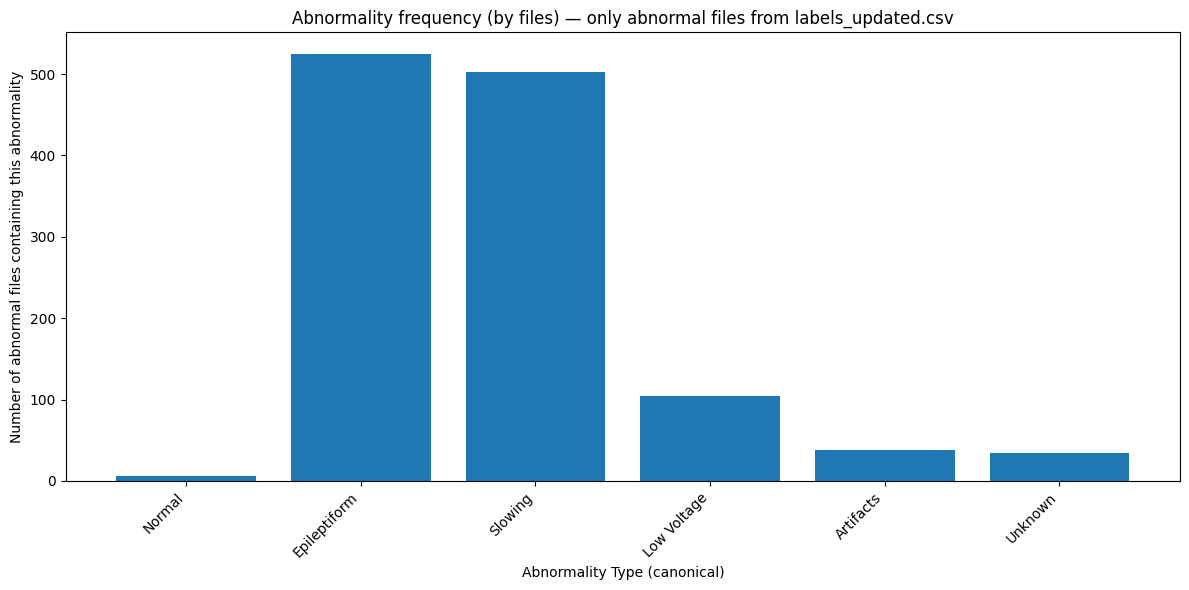

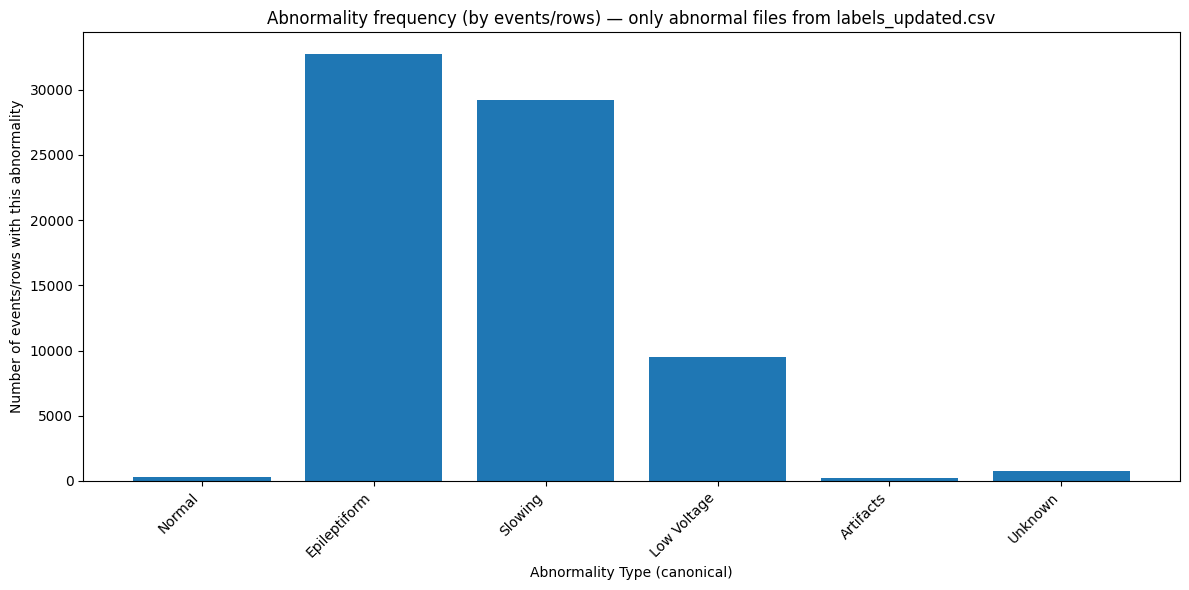

In [86]:
# ---------------------------
# 5) Stats (ORDER-PRESERVED):
#    - event_count: how many rows/events of each abnormality
#    - file_count : how many abnormal files contain that abnormality at least once
# ---------------------------
event_counts = mapped_df["abnormality"].value_counts()
file_counts = mapped_df.drop_duplicates(["file", "abnormality"])["abnormality"].value_counts()

# Build stats table in canonical order (include all labels even if count=0)
stats_df = pd.DataFrame(index=canonical_order)
stats_df["event_count"] = event_counts.reindex(canonical_order, fill_value=0).astype(int)
stats_df["file_count"]  = file_counts.reindex(canonical_order, fill_value=0).astype(int)

display(stats_df)

# ---------------------------
# 6) Graphs (ORDER-PRESERVED)
# ---------------------------
plt.figure(figsize=(12, 6))
plt.bar(stats_df.index, stats_df["file_count"].values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Abnormality Type (canonical)")
plt.ylabel("Number of abnormal files containing this abnormality")
plt.title("Abnormality frequency (by files) — only abnormal files from labels_updated.csv")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(stats_df.index, stats_df["event_count"].values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Abnormality Type (canonical)")
plt.ylabel("Number of events/rows with this abnormality")
plt.title("Abnormality frequency (by events/rows) — only abnormal files from labels_updated.csv")
plt.tight_layout()
plt.show()



=== Multi-abnormality summary ===
Total abnormal files loaded: 958
Files with multiple abnormalities (>1): 203
Percentage: 21.19%


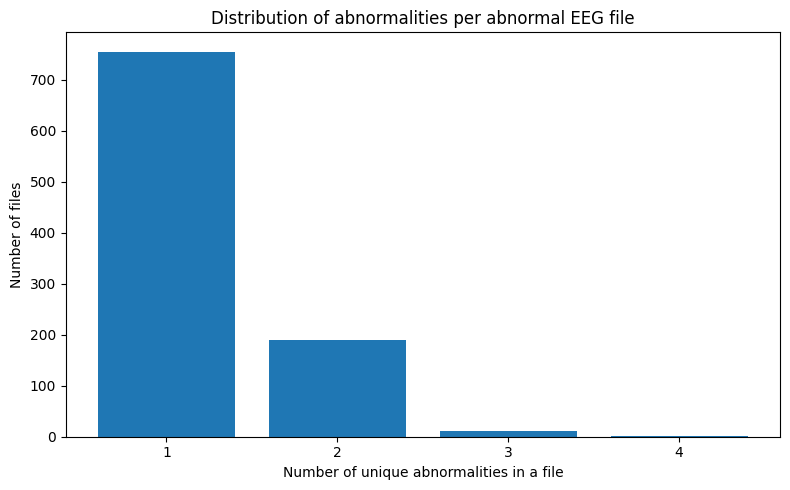

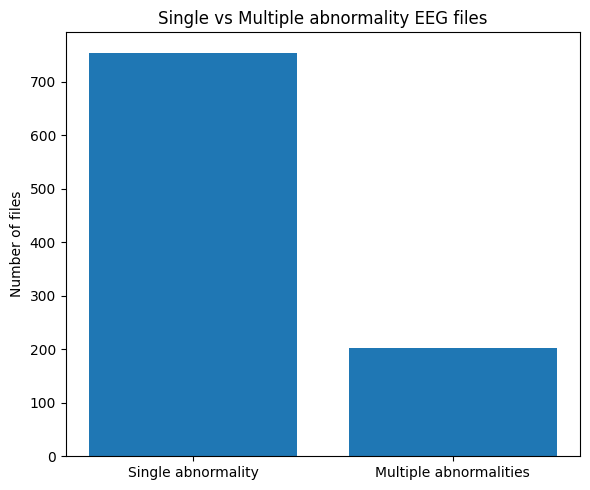


=== Multi-abnormality files (first 50) ===


,file,abnormalities
0,ffh_2024_0000007,"[Artifacts, Low Voltage, Slowing]"
1,ffh_2024_0000046,"[Artifacts, Low Voltage]"
2,ffh_2024_0000053,"[Artifacts, Epileptiform, Low Voltage, Slowing]"
3,ffh_2024_0000055,"[Artifacts, Low Voltage]"
4,ffh_2024_0000059,"[Artifacts, Low Voltage]"
5,ffh_2024_0000061,"[Artifacts, Low Voltage]"
6,ffh_2024_0000069,"[Artifacts, Low Voltage]"
7,ffh_2024_0000071,"[Artifacts, Low Voltage, Slowing]"
8,ffh_2024_0000073,"[Artifacts, Slowing]"
9,ffh_2024_0000076,"[Epileptiform, Slowing]"


In [87]:
# =========================
# 5) Multi-abnormality analysis
# =========================
# Remove Unknown for multi-abnormality counting (recommended)
tmp = mapped_df[mapped_df["abnormality"] != "Unknown"].copy()

abnormalities_per_file = (
    tmp.groupby("file")["abnormality"]
    .nunique()
    .reset_index(name="num_abnormalities")
)

total_files_loaded = abnormalities_per_file.shape[0]
multi_abnormal_files = abnormalities_per_file[abnormalities_per_file["num_abnormalities"] > 1]

print("\n=== Multi-abnormality summary ===")
print(f"Total abnormal files loaded: {total_files_loaded}")
print(f"Files with multiple abnormalities (>1): {multi_abnormal_files.shape[0]}")
if total_files_loaded > 0:
    print(f"Percentage: {100 * multi_abnormal_files.shape[0] / total_files_loaded:.2f}%")

# =========================
# 6) Graph 1: Distribution of #abnormalities per file
# =========================
dist_counts = abnormalities_per_file["num_abnormalities"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(dist_counts.index.astype(str), dist_counts.values)
plt.xlabel("Number of unique abnormalities in a file")
plt.ylabel("Number of files")
plt.title("Distribution of abnormalities per abnormal EEG file")
plt.tight_layout()
plt.show()

# =========================
# 7) Graph 2: Single vs Multiple
# =========================
binary_df = abnormalities_per_file.copy()
binary_df["group"] = binary_df["num_abnormalities"].apply(lambda x: "Single abnormality" if x == 1 else "Multiple abnormalities")
binary_counts = binary_df["group"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(binary_counts.index, binary_counts.values)
plt.ylabel("Number of files")
plt.title("Single vs Multiple abnormality EEG files")
plt.tight_layout()
plt.show()

# =========================
# 8) Table: multi-abnormality files + their abnormality sets
# =========================
file_to_abnormalities = (
    tmp.groupby("file")["abnormality"]
    .apply(lambda x: sorted(set(x)))
)

multi_abnormal_sets = file_to_abnormalities[file_to_abnormalities.apply(len) > 1].reset_index()
multi_abnormal_sets.columns = ["file", "abnormalities"]

print("\n=== Multi-abnormality files (first 50) ===")
display(multi_abnormal_sets.head(50))

# Optional: save to CSV
# multi_abnormal_sets.to_csv("multi_abnormal_files_and_types.csv", index=False)


In [88]:
import numpy as np
import matplotlib.pyplot as plt

# mapped_df must already exist with columns: ["file", "abnormality"]

# 1) Remove Unknown (recommended)
df = mapped_df[mapped_df["abnormality"] != "Unknown"].copy()

# 2) File × abnormality presence matrix
presence = (
    df.drop_duplicates(["file", "abnormality"])
      .assign(present=1)
      .pivot_table(index="file", columns="abnormality",
                   values="present", fill_value=0, aggfunc="max")
)

# 3) Ensure ALL abnormalities exist and follow dictionary order
presence = presence.reindex(columns=canonical_order, fill_value=0)

# 4) Co-occurrence (file-level)
co = presence.T.dot(presence)

# Remove diagonal (self-counts)
co_nodiag = co.copy()
np.fill_diagonal(co_nodiag.values, 0)

pairs = []
for i, a in enumerate(canonical_order):
    for j in range(i + 1, len(canonical_order)):
        b = canonical_order[j]
        count = int(co_nodiag.loc[a, b])
        if count > 0:
            pairs.append((a, b, count))

pairs_df = pd.DataFrame(
    pairs, columns=["Abnormality A", "Abnormality B", "File Co-occurrence Count"]
).sort_values("File Co-occurrence Count", ascending=False)

display(pairs_df.head(20))


,Abnormality A,Abnormality B,File Co-occurrence Count
1,Epileptiform,Slowing,163
6,Low Voltage,Artifacts,21
3,Epileptiform,Artifacts,17
5,Slowing,Artifacts,15
4,Slowing,Low Voltage,12
0,Normal,Slowing,5
2,Epileptiform,Low Voltage,2


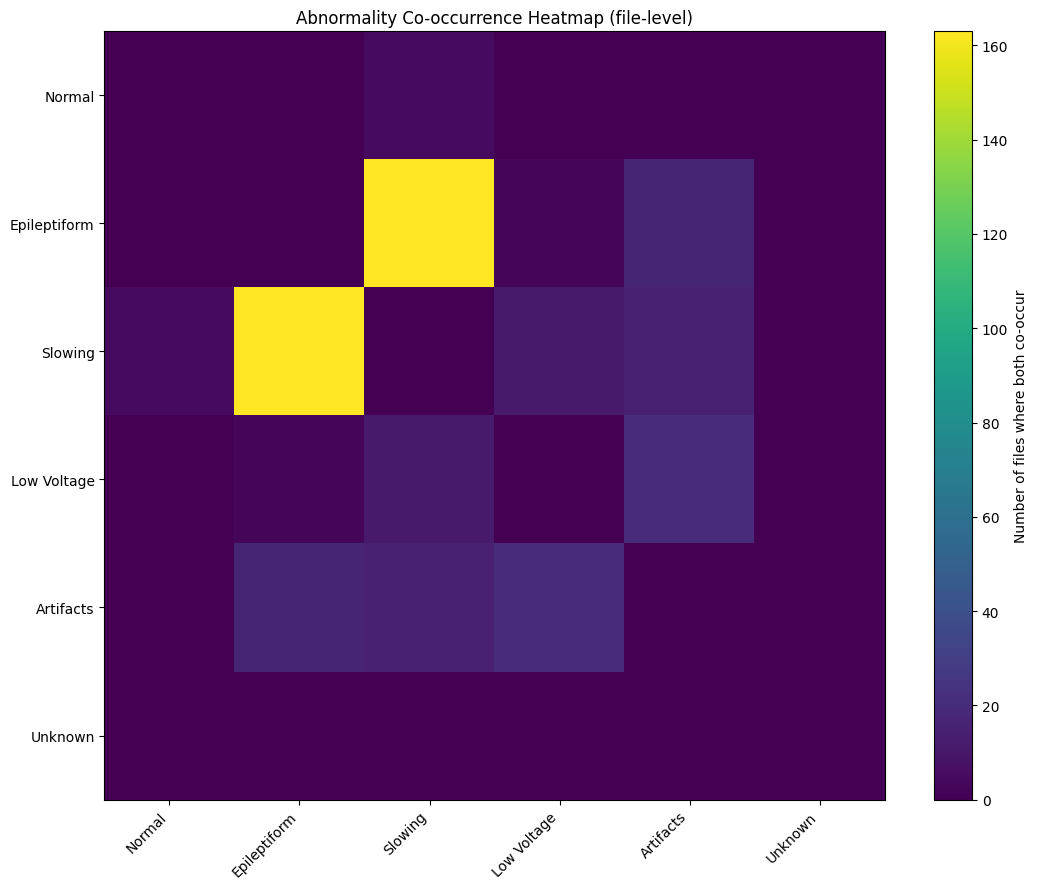

abnormality,Normal,Epileptiform,Slowing,Low Voltage,Artifacts,Unknown
abnormality,,,,,,
Normal,0,0,5,0,0,0
Epileptiform,0,0,163,2,17,0
Slowing,5,163,0,12,15,0
Low Voltage,0,2,12,0,21,0
Artifacts,0,17,15,21,0,0
Unknown,0,0,0,0,0,0


In [89]:
plt.figure(figsize=(11, 9))
plt.imshow(co_nodiag.values, aspect="auto")
plt.xticks(range(len(canonical_order)), canonical_order, rotation=45, ha="right")
plt.yticks(range(len(canonical_order)), canonical_order)
plt.colorbar(label="Number of files where both co-occur")
plt.title("Abnormality Co-occurrence Heatmap (file-level)")
plt.tight_layout()
plt.show()

# Optional: show numeric table
display(co_nodiag)


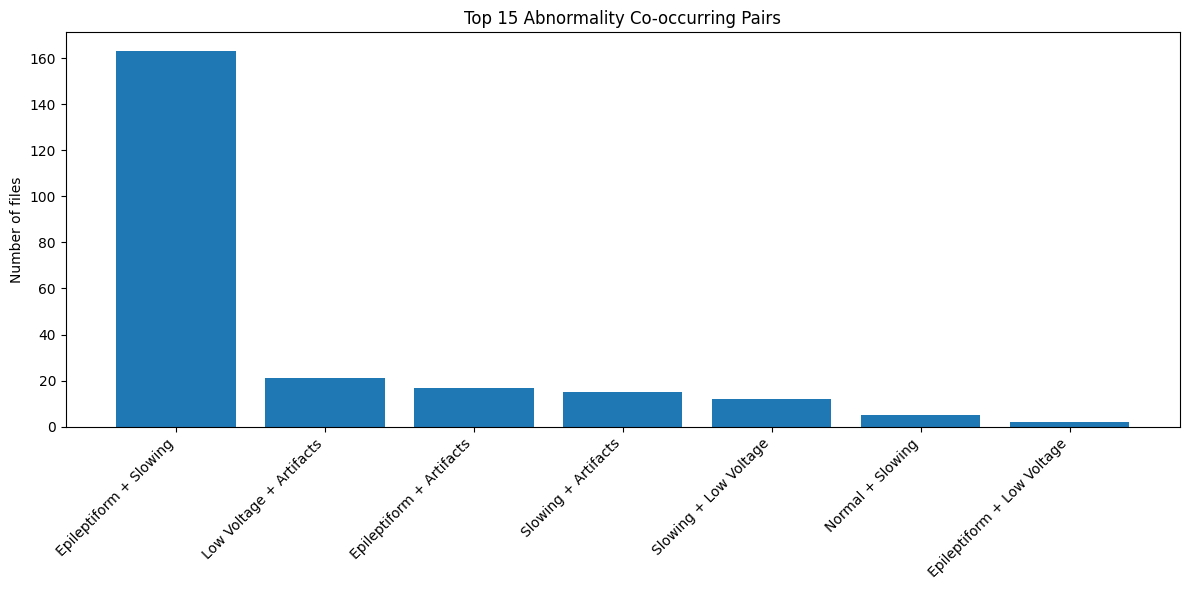

In [90]:
TOP_K = 15
top = pairs_df.head(TOP_K)

plt.figure(figsize=(12, 6))
plt.bar(
    [f"{a} + {b}" for a, b in zip(top["Abnormality A"], top["Abnormality B"])],
    top["File Co-occurrence Count"].values
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of files")
plt.title(f"Top {TOP_K} Abnormality Co-occurring Pairs")
plt.tight_layout()
plt.show()


In [91]:
# mapped_df already exists: columns = ["file", "abnormality"]

# Remove Unknown (recommended)
df = mapped_df[mapped_df["abnormality"] != "Unknown"].copy()

# File × abnormality presence
presence = (
    df.drop_duplicates(["file", "abnormality"])
      .assign(present=1)
      .pivot_table(index="file",
                   columns="abnormality",
                   values="present",
                   fill_value=0,
                   aggfunc="max")
)

# Ensure canonical order
presence = presence.reindex(columns=canonical_order, fill_value=0)

# labels_df = pd.read_csv("labels_updated.csv")

FILE_COL = "file_name"
AGE_COL = "age"
GENDER_COL = "gender"

meta = labels_df[[FILE_COL, AGE_COL, GENDER_COL]].drop_duplicates()
meta = meta.rename(columns={FILE_COL: "file"})

# Merge metadata with presence matrix
presence_meta = presence.reset_index().merge(meta, on="file", how="left")

display(presence_meta.head())


,file,Normal,Epileptiform,Slowing,Low Voltage,Artifacts,Unknown,age,gender
0,ffh_2024_0000007,0,0,1,1,1,0,15.0,male
1,ffh_2024_0000046,0,0,0,1,1,0,32.0,female
2,ffh_2024_0000053,0,1,1,1,1,0,62.0,female
3,ffh_2024_0000054,0,0,1,0,0,0,66.0,male
4,ffh_2024_0000055,0,0,0,1,1,0,69.0,female


,abnormality,age_group,file_count
0,Normal,0–10,0
1,Normal,11–20,0
2,Normal,21–30,3
3,Normal,31–40,0
4,Normal,41–50,2


<Figure size 1400x700 with 0 Axes>

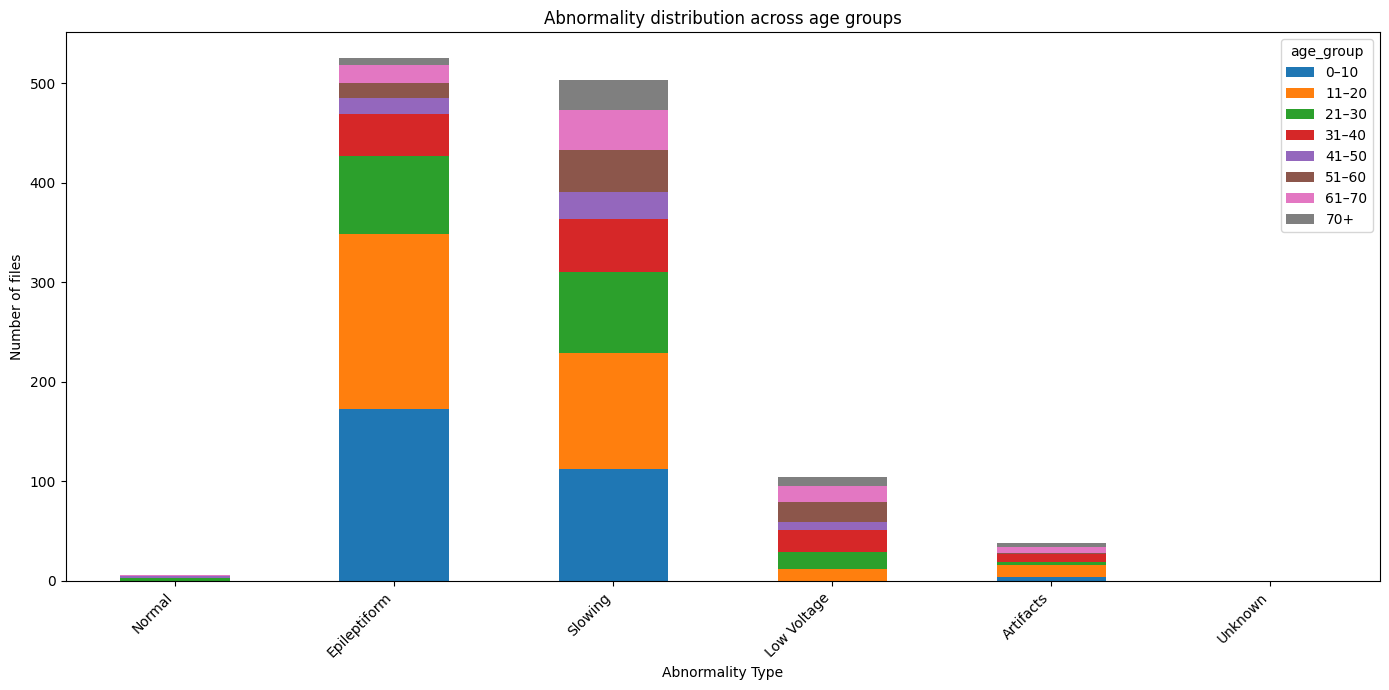

In [92]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 120]
age_labels = ["0–10", "11–20", "21–30", "31–40", "41–50", "51–60", "61–70", "70+"]

presence_meta["age_group"] = pd.cut(
    presence_meta[AGE_COL],
    bins=age_bins,
    labels=age_labels,
    right=True
)
age_dist = []

for ab in canonical_order:
    for ag in age_labels:
        count = presence_meta.loc[
            (presence_meta["age_group"] == ag) & (presence_meta[ab] == 1)
        ].shape[0]
        age_dist.append((ab, ag, count))

age_dist_df = pd.DataFrame(age_dist, columns=["abnormality", "age_group", "file_count"])

display(age_dist_df.head())
age_pivot = age_dist_df.pivot(
    index="abnormality",
    columns="age_group",
    values="file_count"
).reindex(canonical_order)

plt.figure(figsize=(14, 7))
age_pivot.plot(kind="bar", stacked=True, figsize=(14, 7))
plt.xlabel("Abnormality Type")
plt.ylabel("Number of files")
plt.title("Abnormality distribution across age groups")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,abnormality,gender,file_count
0,Normal,Male,5
1,Normal,Female,1
2,Normal,Other,0
3,Epileptiform,Male,304
4,Epileptiform,Female,221


<Figure size 1400x700 with 0 Axes>

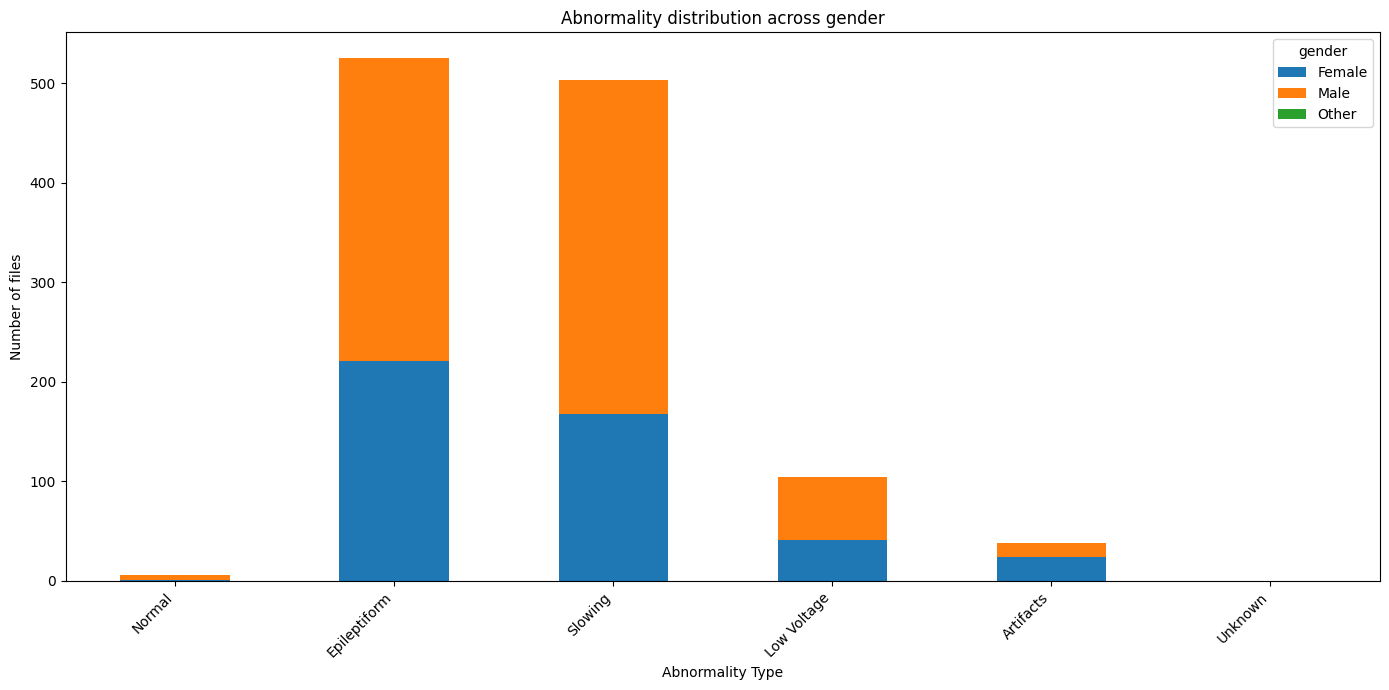

In [93]:
def normalize_gender(g):
    if pd.isna(g):
        return "Unknown"
    g = str(g).strip().lower()
    if g in ["m", "male"]:
        return "Male"
    if g in ["f", "female"]:
        return "Female"
    return "Other"

presence_meta["gender_norm"] = presence_meta[GENDER_COL].apply(normalize_gender)

gender_dist = []

for ab in canonical_order:
    for g in ["Male", "Female", "Other"]:
        count = presence_meta.loc[
            (presence_meta["gender_norm"] == g) & (presence_meta[ab] == 1)
        ].shape[0]
        gender_dist.append((ab, g, count))

gender_dist_df = pd.DataFrame(
    gender_dist, columns=["abnormality", "gender", "file_count"]
)

display(gender_dist_df.head())

gender_pivot = gender_dist_df.pivot(
    index="abnormality",
    columns="gender",
    values="file_count"
).reindex(canonical_order)

plt.figure(figsize=(14, 7))
gender_pivot.plot(kind="bar", stacked=True, figsize=(14, 7))
plt.xlabel("Abnormality Type")
plt.ylabel("Number of files")
plt.title("Abnormality distribution across gender")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


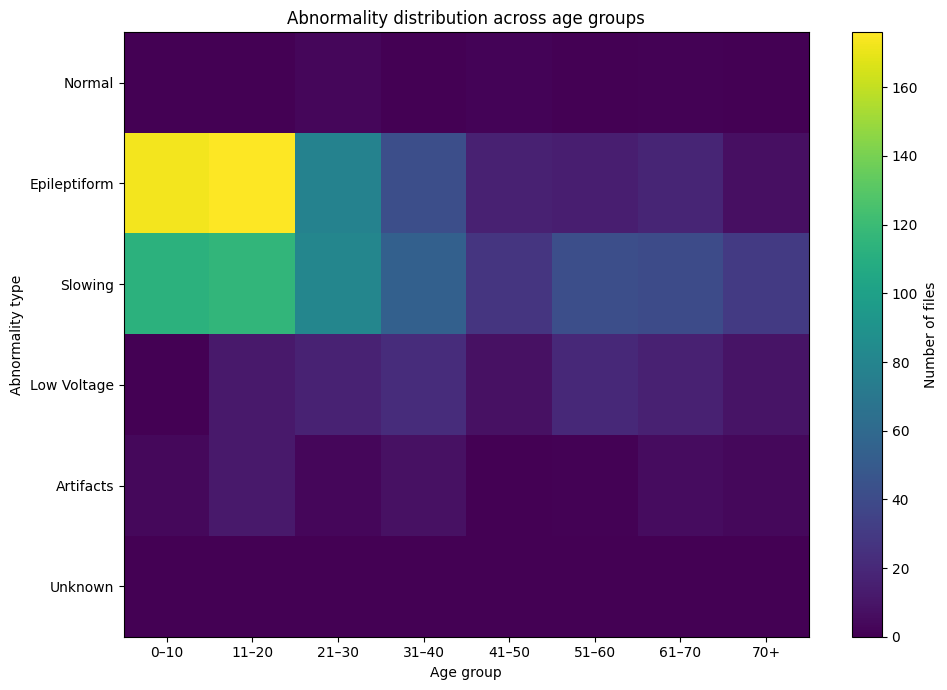

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# age_pivot already created earlier:
# index = abnormality, columns = age_group, values = file_count

# Ensure canonical order
age_pivot = age_pivot.reindex(canonical_order)

plt.figure(figsize=(10, 7))
plt.imshow(age_pivot.values, aspect="auto")

plt.xticks(range(len(age_pivot.columns)), age_pivot.columns)
plt.yticks(range(len(age_pivot.index)), age_pivot.index)

plt.colorbar(label="Number of files")
plt.title("Abnormality distribution across age groups")
plt.xlabel("Age group")
plt.ylabel("Abnormality type")

plt.tight_layout()
plt.show()


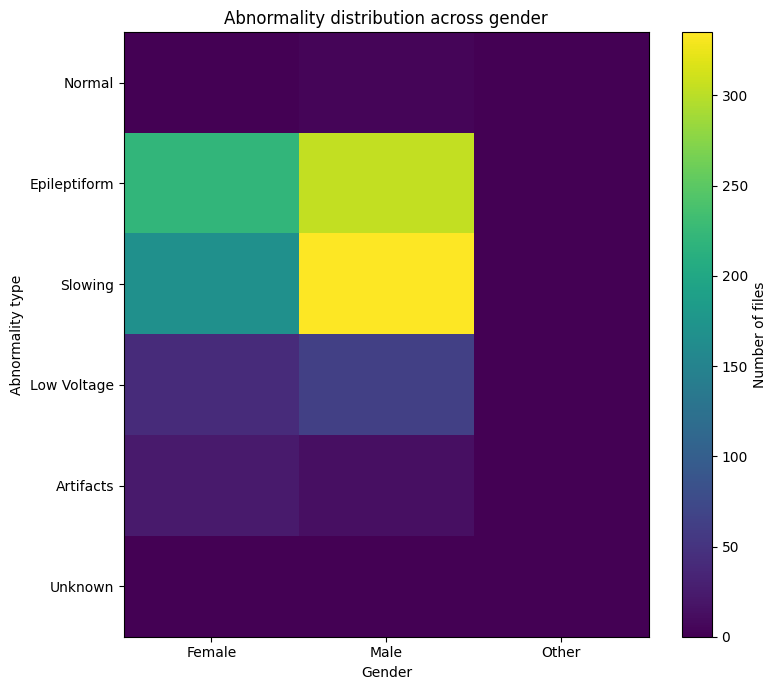

In [95]:
gender_pivot = gender_pivot.reindex(canonical_order)

plt.figure(figsize=(8, 7))
plt.imshow(gender_pivot.values, aspect="auto")

plt.xticks(range(len(gender_pivot.columns)), gender_pivot.columns)
plt.yticks(range(len(gender_pivot.index)), gender_pivot.index)

plt.colorbar(label="Number of files")
plt.title("Abnormality distribution across gender")
plt.xlabel("Gender")
plt.ylabel("Abnormality type")

plt.tight_layout()
plt.show()


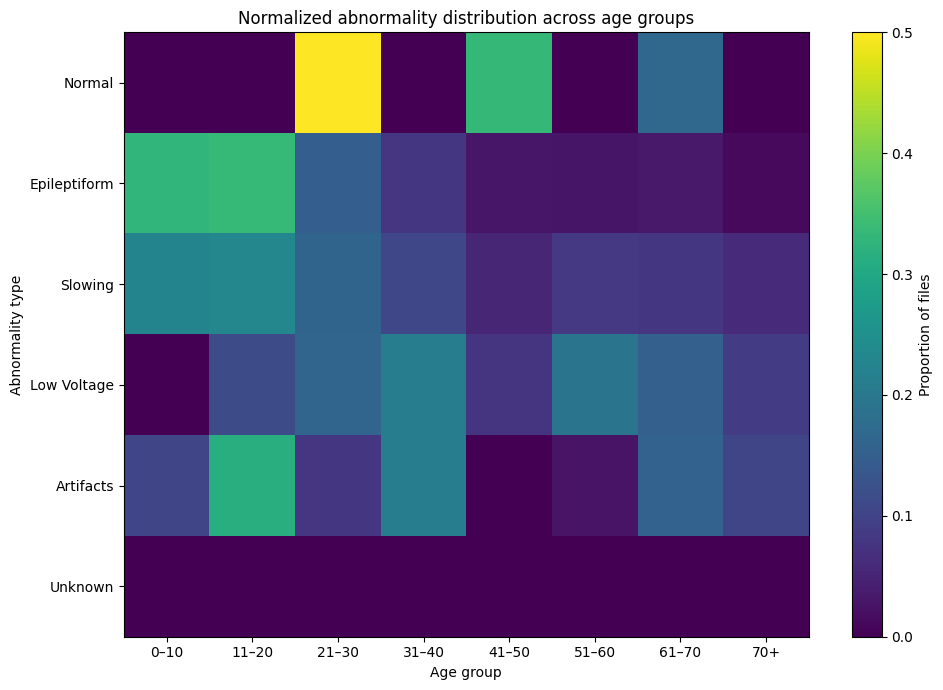

In [96]:
age_norm = age_pivot.div(age_pivot.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(10, 7))
plt.imshow(age_norm.values, aspect="auto")

plt.xticks(range(len(age_norm.columns)), age_norm.columns)
plt.yticks(range(len(age_norm.index)), age_norm.index)

plt.colorbar(label="Proportion of files")
plt.title("Normalized abnormality distribution across age groups")
plt.xlabel("Age group")
plt.ylabel("Abnormality type")

plt.tight_layout()
plt.show()


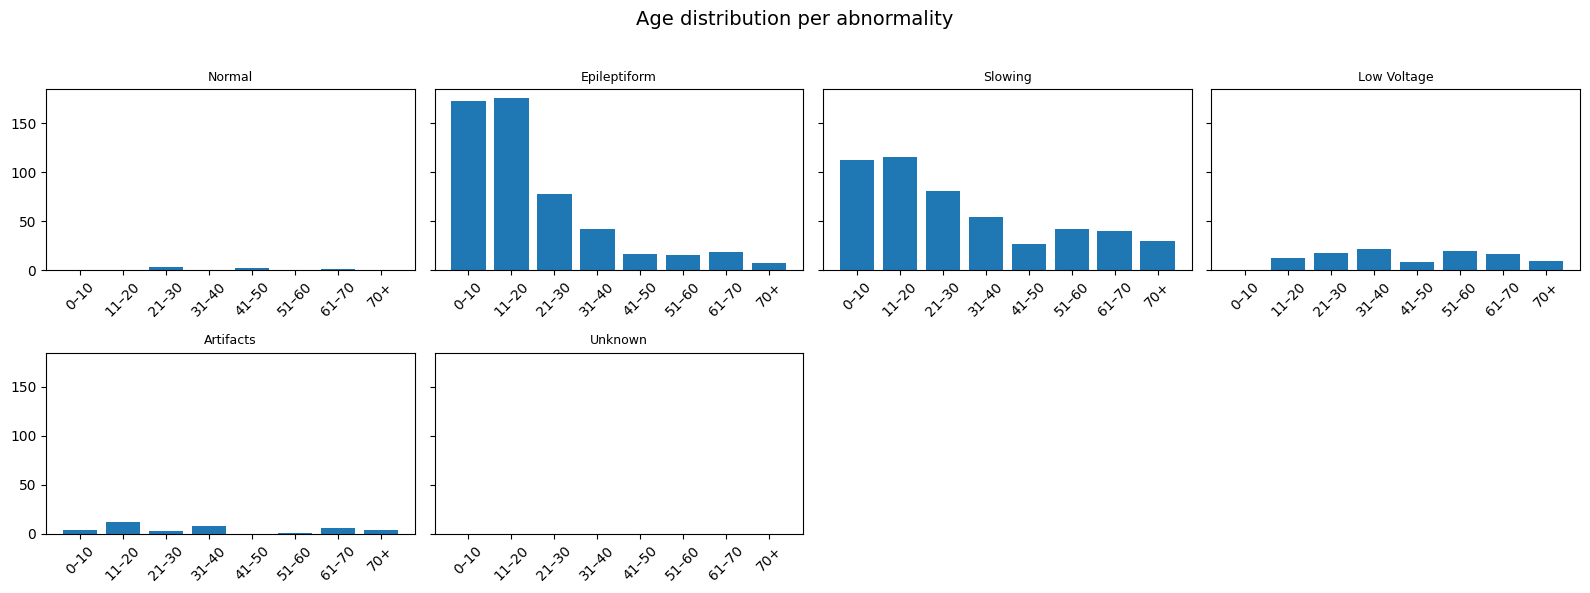

In [97]:
import math

n = len(canonical_order)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3), sharey=True)
axes = axes.flatten()

for i, ab in enumerate(canonical_order):
    axes[i].bar(age_pivot.columns, age_pivot.loc[ab].values)
    axes[i].set_title(ab, fontsize=9)
    axes[i].tick_params(axis='x', rotation=45)

# remove empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Age distribution per abnormality", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
